This template validates the diagnostic (`.diag`) files from a LOGR | Solar. A diagnostic file is the logger reporting on itself: one row a minute carrying the Avg, Min, Max and SD of every internal supply rail and of the current drawn from it. Nothing in it measures the site, so nothing in it is interesting until something is wrong.

Every check in `diagnostics.SPEC` is run, the results are summarized, and every signal is plotted for visual inspection. Use `Process_LOGR_Diag_Files.ipynb` instead if you only want to read and plot the files.

In [1]:
import pandas as pd

from se_analysis import diagnostics, project, read_files, validation
from se_analysis.plot import plot_signals, plot_together

A `SPEC` says what a healthy file looks like: the volts each rail should hold, the current it may draw, how far a statistic may spread within one minute, and which signals should never sit still. Any spec can be over-ridden for a logger that legitimately differs.

In [2]:
# The standard LOGR | Solar diagnostic expectations, used unchanged here. A
# logger that legitimately differs -- more sensors hanging off a COM excitation
# output, say -- over-rides only what differs:
#
#     spec = diagnostics.SPEC.override(
#         ranges={"COMA EXC_mA_Max": (0, 400)},
#     )
spec = diagnostics.SPEC

Modify this cell to point to the directory holding the `.diag` files. `project` finds your configured project directory, set in the `SE_PROJECTS_DIR` variable in the `.env` file.

In [3]:
data_dir = project("SRM", "Panama-NE", "data", "MET1", "MET")
reader = read_files(data_dir, file_type="diag")

2026-09-14 16:25:04,693 | INFO | [logr:559] | Concatenating 27 files...


Time elapsed: 0 s | 27  / 27  [=============================================] 100%	

2026-09-14 16:25:04,857 | INFO | [logr:677] | Concatenation of 1439 rows complete


Display the site info to make sure you're using the correct data files.

In [4]:
reader.Site_info

,0,1
0,Model Number:,9432
1,Serial Number:,3130
2,Created FW Version:,1.13.06
3,Site Properties,NaN
4,Site:,3130
5,Project:,Panama Solar
6,Location:,MET#1 INV-23A104
7,Latitude:,40.31506
8,Longitude:,-96.43596
9,Elevation:,402


`indexed` puts the frame on its statistics timestamp, oldest first. The stamps are written with a `Z`, so unlike the ProtoNode exports these files are already UTC.

In [5]:
df = diagnostics.indexed(reader.data)
df

,VIN_RP_V_Avg,VIN_RP_V_Min,VIN_RP_V_Max,VIN_RP_V_SD,12_4V_V_Avg,12_4V_V_Min,12_4V_V_Max,12_4V_V_SD,12_4V_mA_Avg,12_4V_mA_Min,...,-VIN_RP_V_Max,-VIN_RP_V_SD,-15V_V_Avg,-15V_V_Min,-15V_V_Max,-15V_V_SD,12V_mA_Avg,12V_mA_Min,12V_mA_Max,12V_mA_SD
Stats_Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-09-10 00:00:00+00:00,23.7392,23.7226,23.7588,0.0089,12.3642,12.3549,12.3731,0.0020,73.5348,49.1575,...,-23.7961,0.0006,-15.1303,-15.1305,-15.1301,0.0001,18.8207,18.7806,18.9281,0.0450
2026-09-10 00:01:00+00:00,23.7384,23.7226,23.7588,0.0088,12.3640,12.3459,12.3731,0.0029,70.4188,48.3517,...,-23.7966,0.0003,-15.1303,-15.1307,-15.1300,0.0003,18.8302,18.7725,18.9400,0.0564
2026-09-10 00:02:00+00:00,23.7356,23.6863,23.7588,0.0120,12.3629,12.3459,12.3640,0.0038,71.3724,49.1575,...,-23.7966,0.0003,-15.1304,-15.1307,-15.1301,0.0002,19.0529,18.7830,19.6337,0.2957
2026-09-10 00:03:00+00:00,23.7378,23.7316,23.7497,0.0057,12.3645,12.3640,12.3731,0.0020,73.2527,46.7399,...,-23.7966,0.0003,-15.1304,-15.1310,-15.1298,0.0004,18.9853,18.7582,19.7773,0.3545
2026-09-10 00:04:00+00:00,23.7372,23.7316,23.7588,0.0078,12.3638,12.3549,12.3731,0.0020,71.8559,47.5458,...,-23.7969,0.0002,-15.1304,-15.1308,-15.1302,0.0002,18.9214,18.7753,19.2923,0.2205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-10 23:55:00+00:00,23.7416,23.7045,23.7679,0.0095,12.3638,12.3549,12.3731,0.0020,72.9304,45.9341,...,-23.8019,0.0002,-15.1330,-15.1335,-15.1326,0.0003,18.5224,18.0440,20.3650,0.7555
2026-09-10 23:56:00+00:00,23.7422,23.7316,23.7679,0.0061,12.3634,12.3549,12.3731,0.0033,73.2796,43.5165,...,-23.8017,0.0004,-15.1330,-15.1334,-15.1328,0.0002,18.2006,18.0445,18.5424,0.2149
2026-09-10 23:57:00+00:00,23.7399,23.7135,23.7679,0.0092,12.3637,12.3549,12.3640,0.0016,72.2454,45.9341,...,-23.8014,0.0004,-15.1331,-15.1333,-15.1329,0.0001,18.1013,18.0521,18.3118,0.0861


Run every check in the spec. `summarize` lists every signal the spec tests, the passing ones included; `findings` holds only the problems.

In [6]:
findings = validation.validate(df, spec)
validation.summarize(findings, spec)

,check,signal,n_findings,pass
0,gap,(all signals),1,False
1,range,-15V_V_Avg,1,False
2,range,-15V_V_Max,1,False
3,range,-15V_V_SD,1,False
4,range,-VIN_RP_V_Avg,1,False
...,...,...,...,...
108,stall,3_3V_mA_SD,0,True
109,stall,COMA EXC_mA_Avg,0,True
110,stall,COMA EXC_mA_SD,0,True
111,stall,COMB EXC_mA_Avg,0,True


All findings, from every check.

In [7]:
findings

,check,signal,detail,value,start,end,duration,n_samples
0,gap,(all signals),no data for 0 days 00:02:00 (~1 samples missing),1,2026-09-10 20:31:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:02:00,0
1,range,-VIN_RP_V_Avg,"outside [-25, -22]",-21.7771,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
2,range,-VIN_RP_V_Max,"outside [-25, -22]",0.0004,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
3,range,13_3V_V_Min,"outside [12.635, 13.965]",0.0004,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
4,range,15V_V_Min,"outside [14.25, 15.75]",0.0004,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
5,range,-15V_V_Avg,"outside [-15.75, -14.25]",-13.59,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
6,range,-15V_V_Max,"outside [-15.75, -14.25]",0.0004,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
7,range,12V_V_Min,"outside [11.4, 12.6]",0.0004,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
8,range,5V_V_Avg,"outside [4.75, 5.25]",4.7081,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1
9,range,5V_V_Min,"outside [4.75, 5.25]",0.0004,2026-09-10 20:33:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:00:00,1


Every range finding here lands on the same minute, `20:33`, and the gap check puts a missing sample immediately before it. Take the stamp out of a finding's `start` column and read the rows either side of it.

In [8]:
event = pd.Timestamp("2026-09-10 20:33", tz="UTC")
window = slice(event - pd.Timedelta("3min"), event + pd.Timedelta("3min"))

df.loc[window, ["VIN_RP_V_Avg", "5V_V_Min", "12V_V_Min", "-15V_V_Avg", "3_3V_V_Avg"]]

,VIN_RP_V_Avg,5V_V_Min,12V_V_Min,-15V_V_Avg,3_3V_V_Avg
Stats_Timestamp,,,,,
2026-09-10 20:30:00+00:00,23.7363,5.0503,12.0778,-15.1282,3.2835
2026-09-10 20:31:00+00:00,23.7369,5.0503,12.0777,-15.1282,3.2850
2026-09-10 20:33:00+00:00,23.7344,0.0004,0.0004,-13.5900,3.2825
2026-09-10 20:34:00+00:00,23.7347,5.0503,12.0778,-15.1287,3.2820
2026-09-10 20:35:00+00:00,23.7360,5.0504,12.0777,-15.1287,3.2821
2026-09-10 20:36:00+00:00,23.7357,5.0504,12.0777,-15.1287,3.2824


The 24 V input never moved, but the rails regulated down from it dropped to zero for part of that minute and recovered. The 3.3 V logic rail stayed up, which is presumably why the logger was still running to record any of it. That reads as a brownout in the regulator section rather than a supply interruption, and is worth chasing if it repeats on other days.

`plot_together` overlays signals on one axes, which is how the input rail and the rails downstream of it get compared. `Min` is the statistic to plot here: the dropout was short enough that it barely moved the Avg.

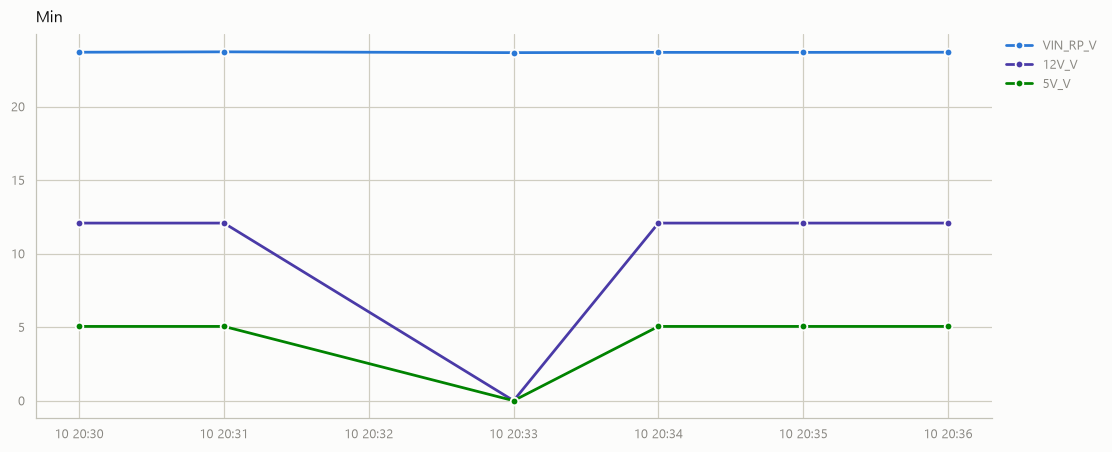

In [9]:
plot_together(df.loc[window], ["VIN_RP_V", "12V_V", "5V_V"], statistic="Min")

Plot every signal to visually inspect. Statistics of the same signal share an axes except SD, which is shown separately since it usually has a much smaller scale.

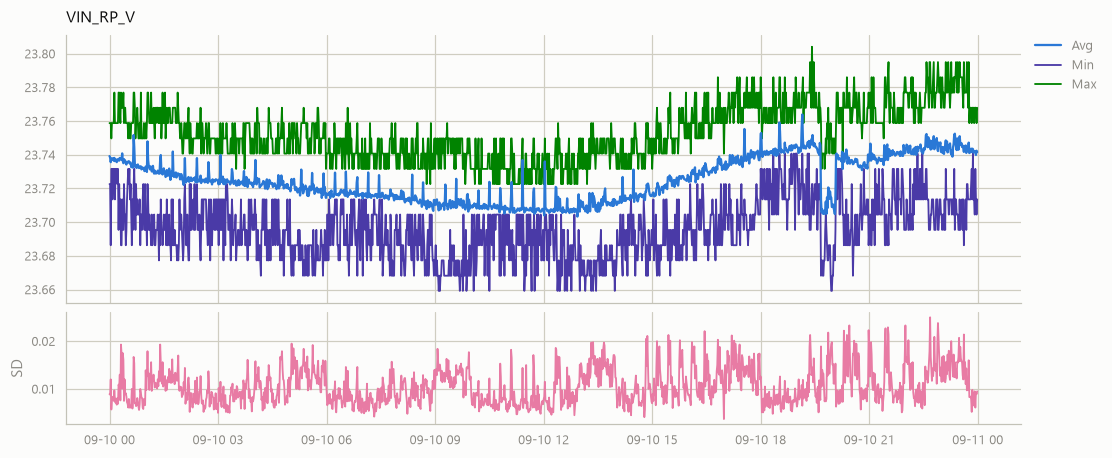

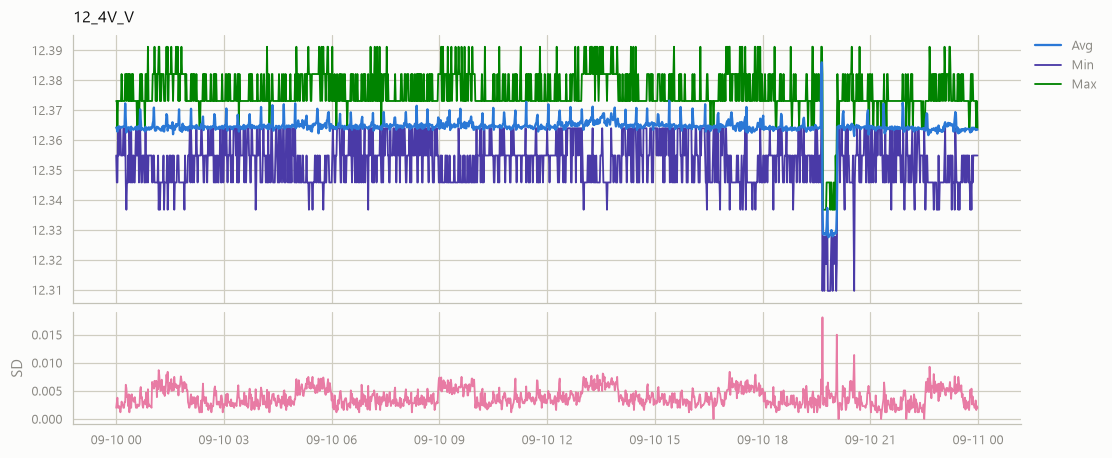

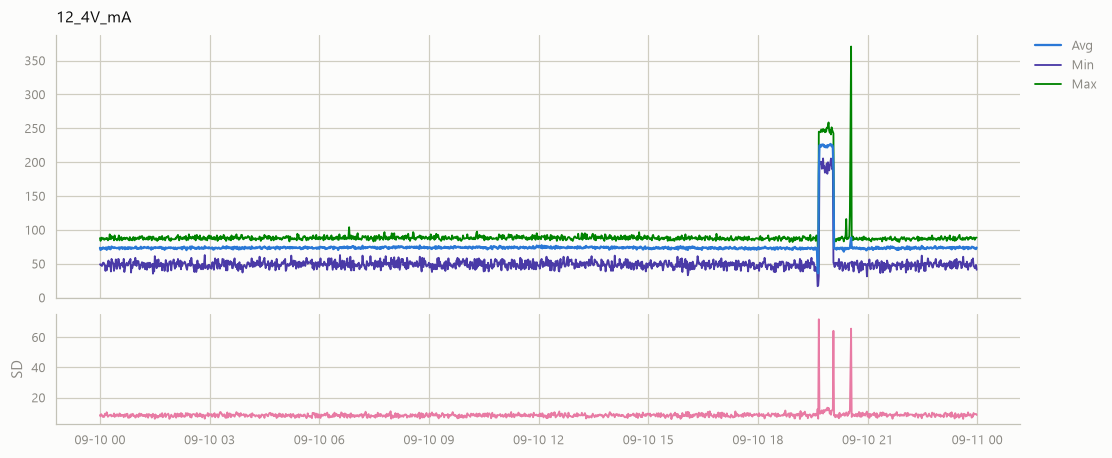

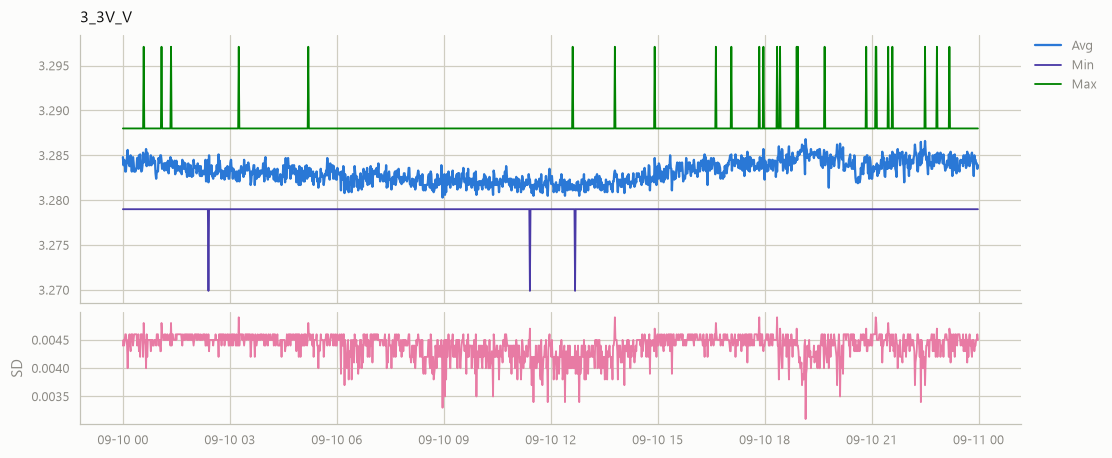

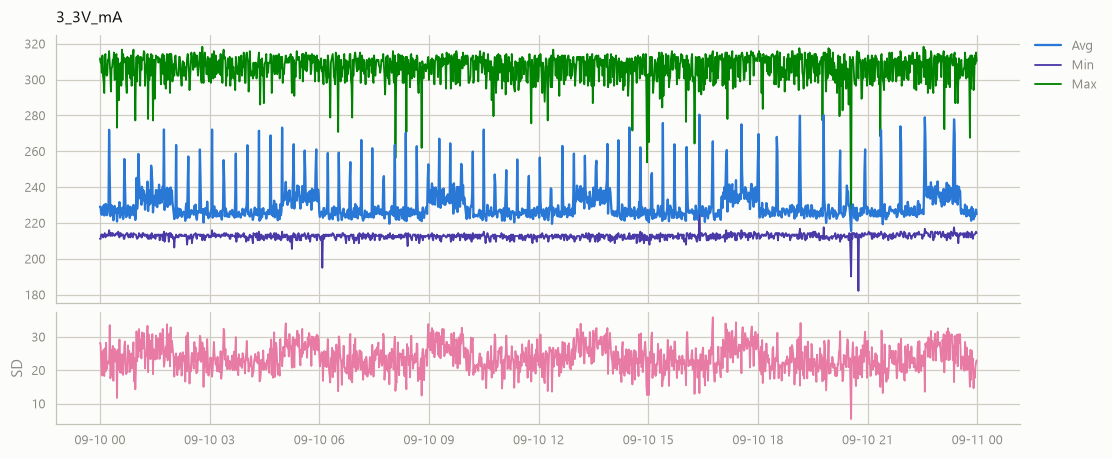

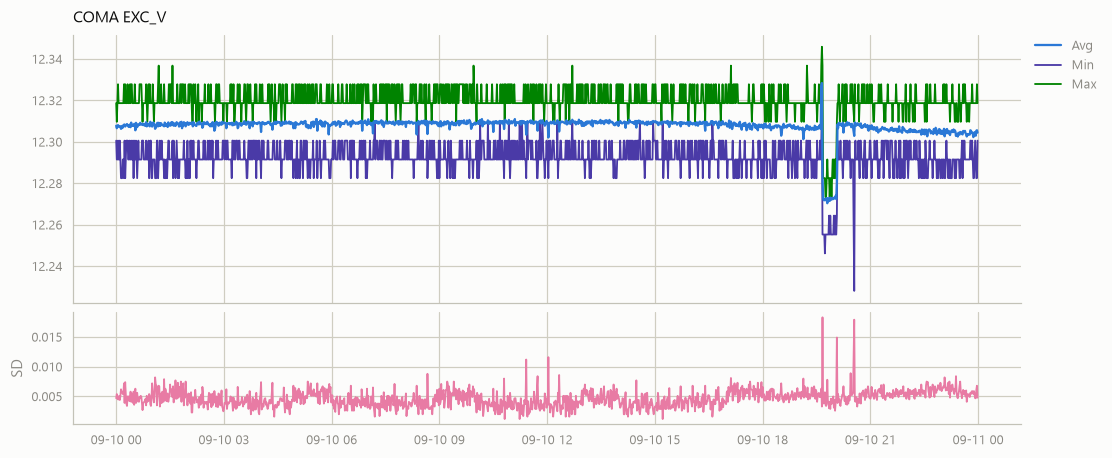

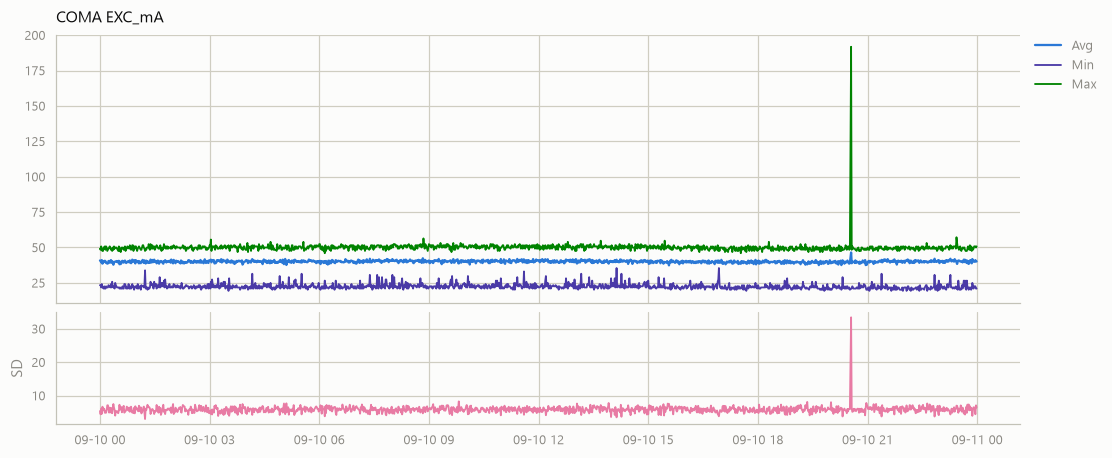

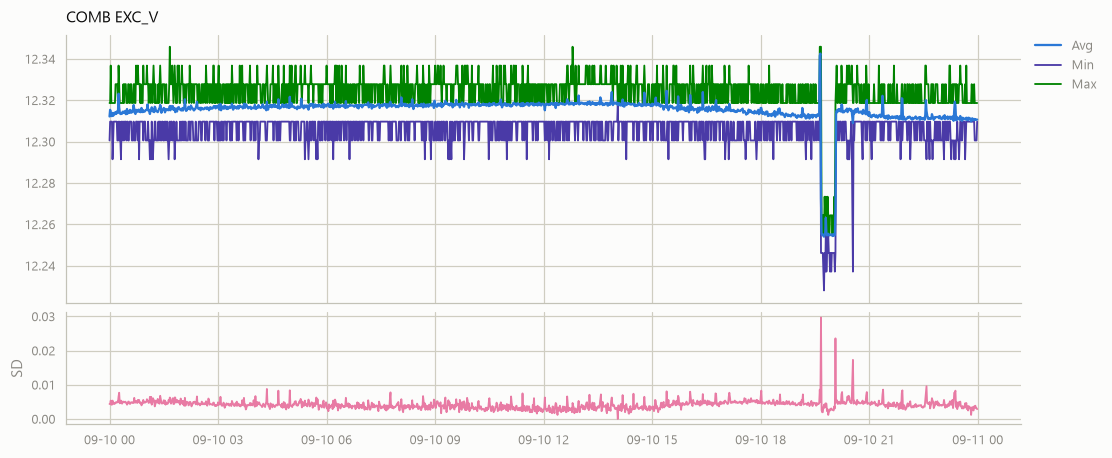

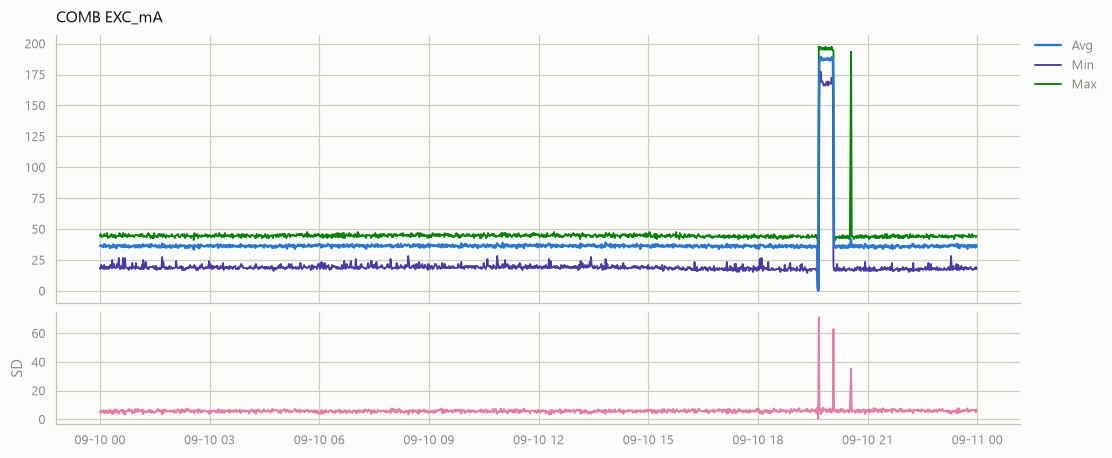

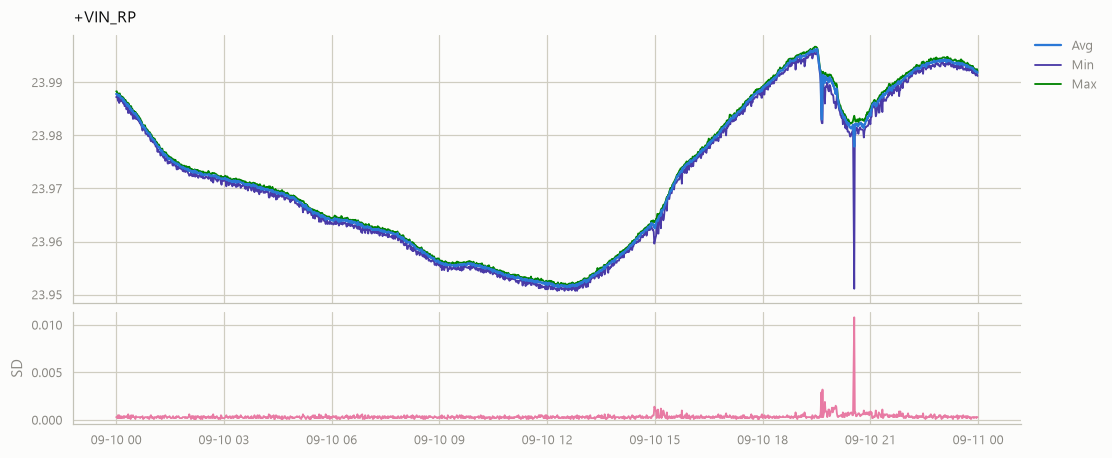

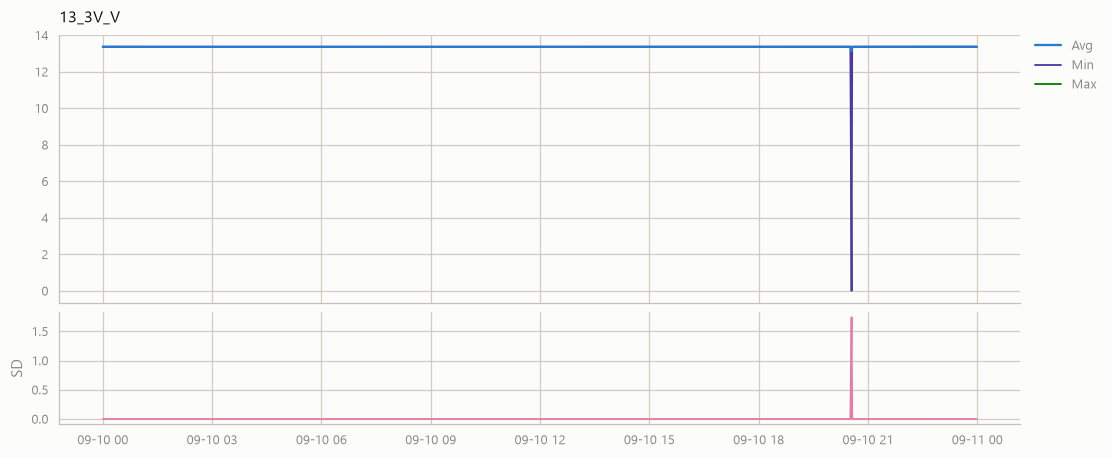

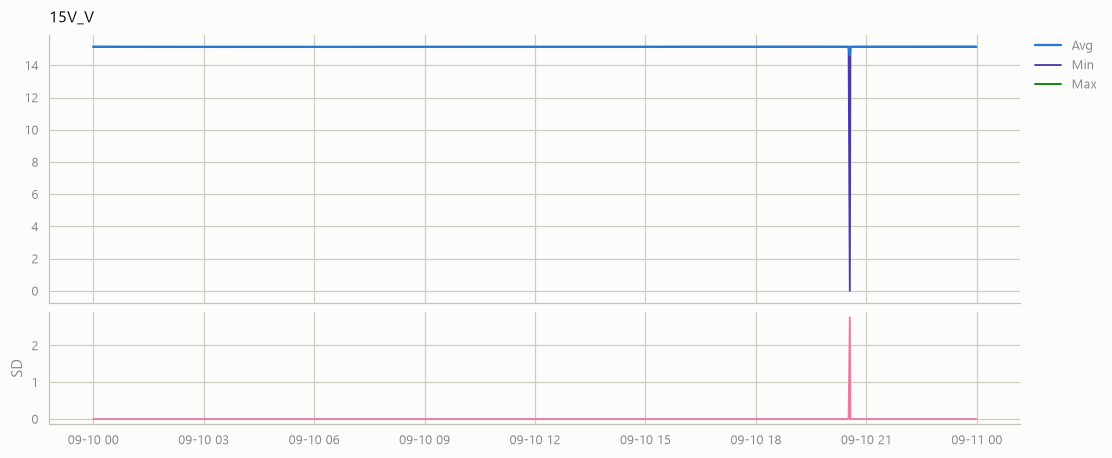

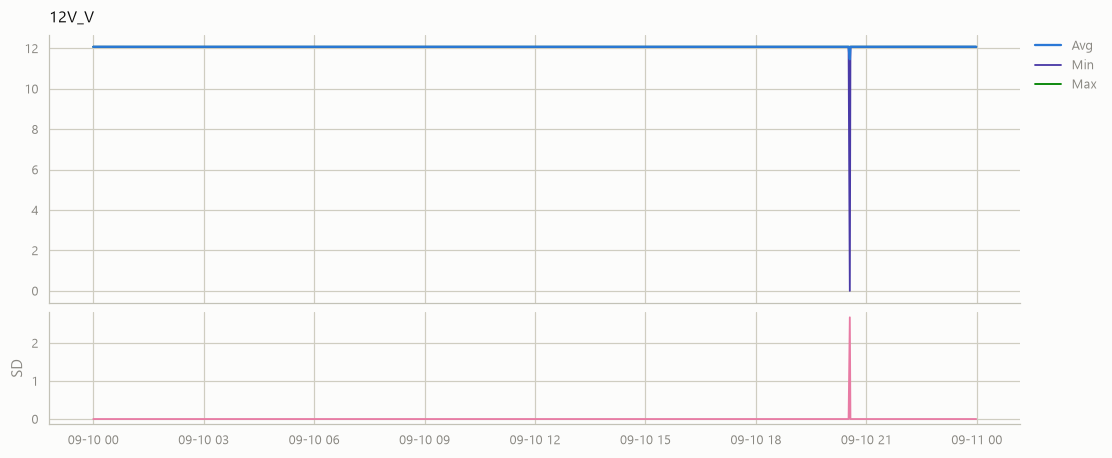

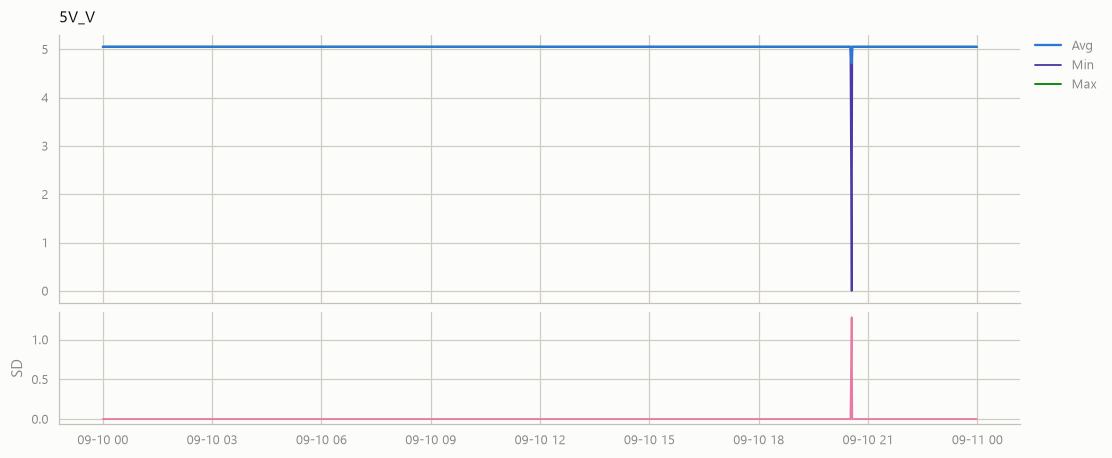

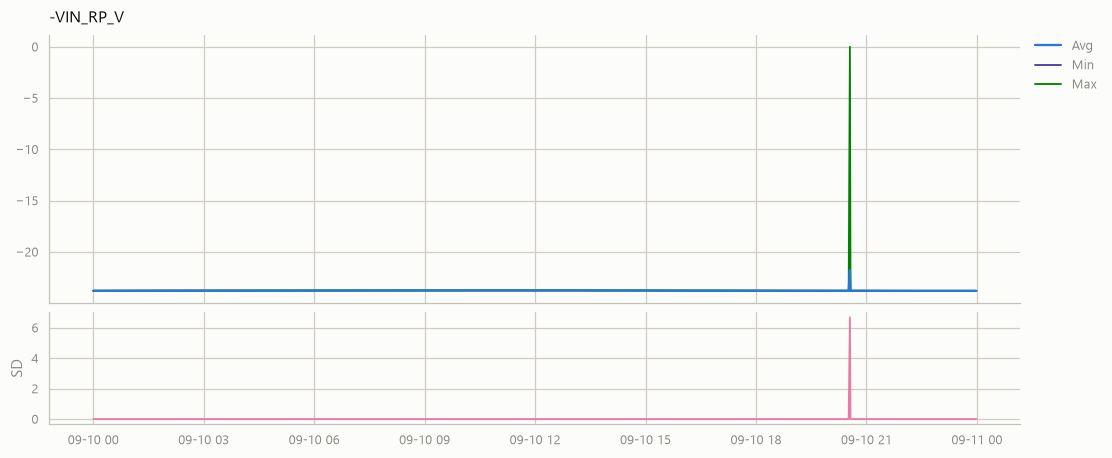

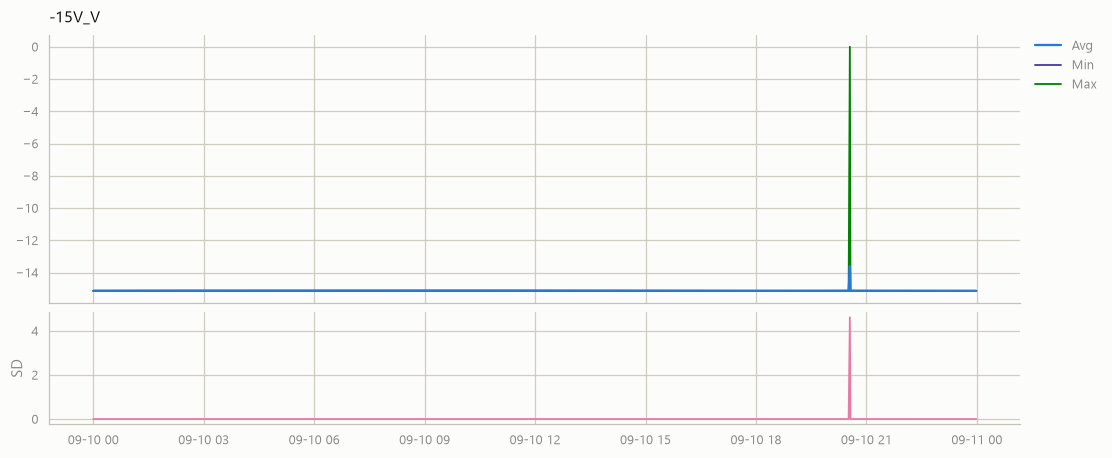

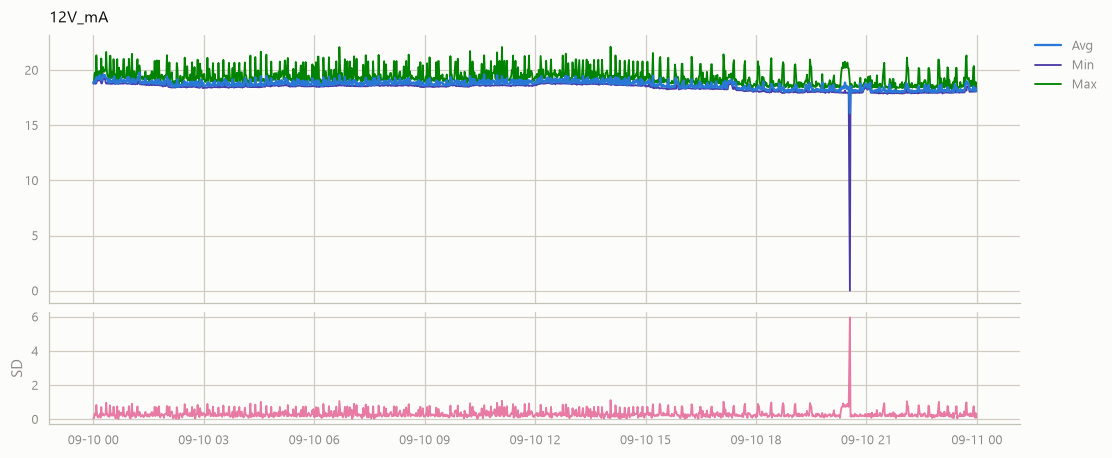

In [10]:
plot_signals(df)